In [6]:
from pathlib import Path
import sys
import torch 

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from instancepipelineprior import get_data_loaders
from bayesianprior.discretizedtrain import EarthquakeCNN, evaluate_metrics, logits_to_magnitude

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = PROJECT_ROOT / "bayesianprior" / "data" / "best_model_weighted2.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)
model = EarthquakeCNN().to(device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()




EarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, str

In [7]:
MIN_MAGNITUDE = 0.0
MAX_MAGNITUDE = 6.6
BIN_WIDTH = 0.1



BIN_CENTERS = torch.arange(
    MIN_MAGNITUDE + BIN_WIDTH / 2,
    MAX_MAGNITUDE,
    BIN_WIDTH,
    dtype=torch.float32
)
NUM_BINS = len(BIN_CENTERS)

In [8]:
import torch
import numpy as np
import pandas as pd

train_loader, val_loader, test_loader = get_data_loaders()

all_predictions = []
all_targets = []

bin_centers = BIN_CENTERS.to(device)

model.eval()

with torch.no_grad():
    for waveforms, magnitudes in test_loader:
        waveforms = waveforms.to(device)
        magnitudes = magnitudes.to(device)

        logits = model(waveforms)
        predictions = logits_to_magnitude(logits, bin_centers)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())

results = pd.DataFrame({
    "true_magnitude": np.array(all_targets),
    "predicted_magnitude": np.array(all_predictions)
})

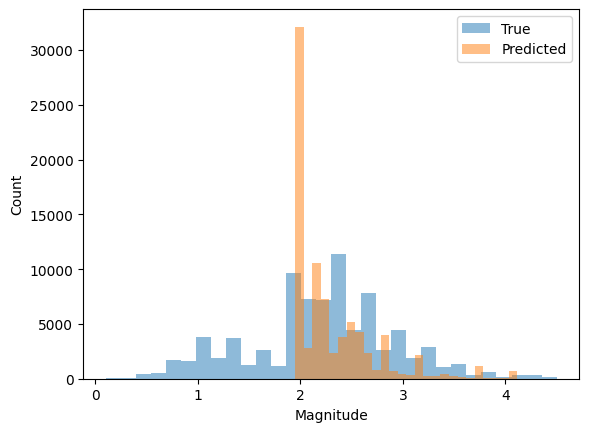

In [9]:
import matplotlib.pyplot as plt

plt.hist(results["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()